In [3]:
import sys
print(sys.executable)

c:\Users\sharm\Desktop\Accident_hotspot_analysis\.venv\Scripts\python.exe



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sharm\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sharm\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


NearestNeighbors(n_neighbors=10)


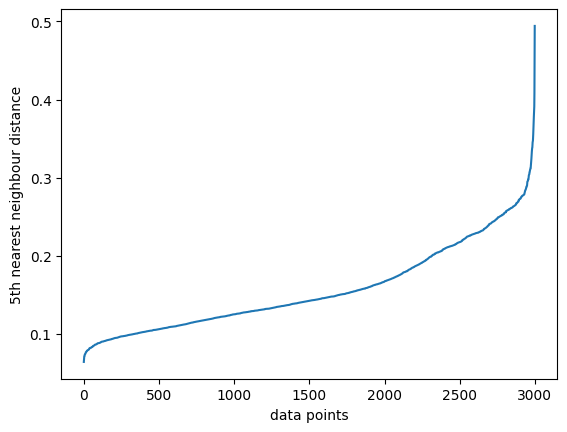

In [4]:
!pip install pandas 
!pip install numpy
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
df=pd.read_csv("rf_favored_accident_dataset_TS_AP_APheavy.csv")
df.isnull()
coordinates=df[["lat","long"]].to_numpy()
neighbours=NearestNeighbors(n_neighbors=10)
neighbours.fit(coordinates)
print(neighbours)
dist,idx=neighbours.kneighbors(coordinates)
dist=np.sort(dist[:,9])
plt.plot(dist)
plt.xlabel("data points")
plt.ylabel("5th nearest neighbour distance")
plt.show()


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sharm\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70
 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93]


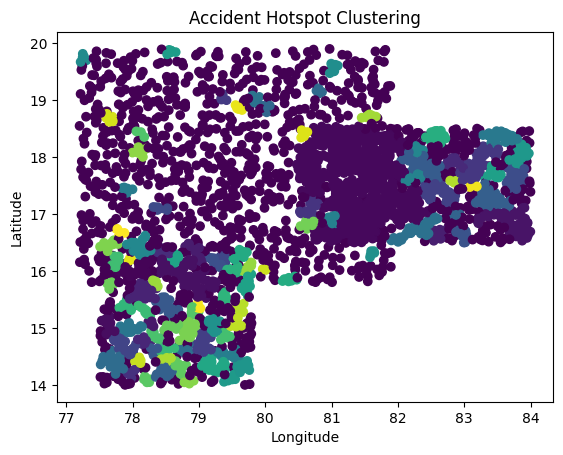

    cluster        lat       long
0         0  16.057237  78.098571
1         1  17.556391  81.391398
2         2  15.047630  77.638395
3         3  15.892301  78.843571
4         4  16.845903  83.704946
..      ...        ...        ...
89       89  16.201589  77.962847
90       90  18.862360  79.594204
91       91  17.482369  83.132729
92       92  15.380933  78.998829
93       93  16.687600  77.798609

[94 rows x 3 columns]


In [5]:
!pip install folium
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster

#Read the Dataset
df=pd.read_csv("rf_favored_accident_dataset_TS_AP_APheavy.csv")
#check for missing values
df.isnull() # o/p: No missing values so need to handle them

#consider only spatial data for clustering
coords = df[["lat", "long"]].to_numpy()

#clustering
dbscan = DBSCAN(eps=0.09, min_samples=5)
labels = dbscan.fit_predict(coords)

# add new column cluster in the df
df["cluster"] = labels
print(np.unique(labels))

#visualization of clusters using scatter plot
plt.scatter(df["long"],df["lat"],c=df["cluster"])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accident Hotspot Clustering")
plt.show()
#print(df["cluster"].value_counts())

#Visualization of clusters on City Map
clustered_df = df[df["cluster"] != -1]  #remove noise values and consider only clustered data



clustered_centers=(clustered_df.groupby("cluster")[["lat","long"]].mean().reset_index())
print(clustered_centers)

# identifying centered lat and long to open the map at the default city
center_lat=df["lat"].mean()
center_long=df["long"].mean()

#creating Blank Map
map=folium.Map(location=[center_lat,center_long],zoom_start=12)

#Creating Bubble Grouping system to view clusters as containers in map
market_cluster= MarkerCluster().add_to(map)

#Adding clusters to the Hotspot Markers

for _, row in clustered_centers.iterrows():
    folium.Marker(
        location=[row["lat"], row["long"]],
        popup=f"Hotspot {row['cluster']}",
        icon=folium.Icon(color="red")
        
    ).add_to(market_cluster)

map.save("Hotspots.html")
